In [2]:
import pandas as pd

USGS

In [ ]:
df = pd.read_csv('data/USGS_data.csv')
df.index = pd.to_datetime(df['DateTime'])
df.drop(columns=['DateTime'], inplace=True)


NLRDB

In [ ]:
df2 = pd.read_csv('data/NLRDB_combined.csv')
df2.index = pd.to_datetime(df2['DateTime'])


Combine

In [10]:
# Combine dfs based on index, fill unknown rows with nan
df_combined = pd.concat([df, df2], axis=1)

C:\Users\epzausch\AppData\Local\Temp\ipykernel_20300\3956496792.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_combined = pd.concat([df, df2], axis=1)


In [11]:
# only keep data post 2018, pre 2025
df_combined = df_combined.loc['2020-01-01':'2024-12-31']
df_combined

,Discharge (cfs),Water Temperature (C),pH (std units),Dissolved Oxygen (mg/L),Specific Conductance (uS/cm),Turbidity (NTU),Year,Month,Day,Hour,...,Relative Humidity,Solar Zenith Angle,SSA,Surface Albedo,Pressure,Precipitable Water,Wind Direction,Wind Speed,DateTime,Smooth Wind Direction
DateTime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,104.0,14.0,7.4,10.4,409.0,29.5,2020.0,1.0,1.0,0.0,...,51.30,170.99,0.93,0.14,1016.0,1.2,36.0,0.6,2020-01-01 00:00:00,0.587785
2020-01-01 00:15:00,104.0,13.9,7.4,10.3,413.0,28.8,2020.0,1.0,1.0,0.0,...,51.64,172.58,0.93,0.14,1016.0,1.3,42.0,0.6,2020-01-01 00:15:00,0.669131
2020-01-01 00:30:00,104.0,13.8,7.4,10.3,416.0,28.9,2020.0,1.0,1.0,0.0,...,51.99,172.83,0.93,0.14,1016.0,1.3,48.0,0.6,2020-01-01 00:30:00,0.743145
2020-01-01 00:45:00,102.0,13.7,7.4,10.2,419.0,28.8,2020.0,1.0,1.0,0.0,...,52.57,171.62,0.93,0.14,1015.0,1.3,54.0,0.6,2020-01-01 00:45:00,0.809017
2020-01-01 01:00:00,102.0,13.6,7.4,10.2,421.0,30.3,2020.0,1.0,1.0,1.0,...,52.92,169.44,0.93,0.14,1015.0,1.3,60.0,0.6,2020-01-01 01:00:00,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:45:00,272.0,18.9,7.5,8.6,219.0,103.0,2024.0,12.0,31.0,22.0,...,100.00,156.63,0.95,0.15,1016.0,2.1,191.0,1.1,2024-12-31 22:45:00,-0.190809
2024-12-31 23:00:00,272.0,18.8,7.5,8.6,220.0,102.0,2024.0,12.0,31.0,23.0,...,100.00,159.78,0.95,0.15,1016.0,2.1,193.0,1.1,2024-12-31 23:00:00,-0.224951
2024-12-31 23:15:00,269.0,18.7,7.4,8.6,222.0,102.0,2024.0,12.0,31.0,23.0,...,100.00,162.87,0.95,0.15,1016.0,2.1,195.0,1.1,2024-12-31 23:15:00,-0.258819


<Axes: xlabel='DateTime'>

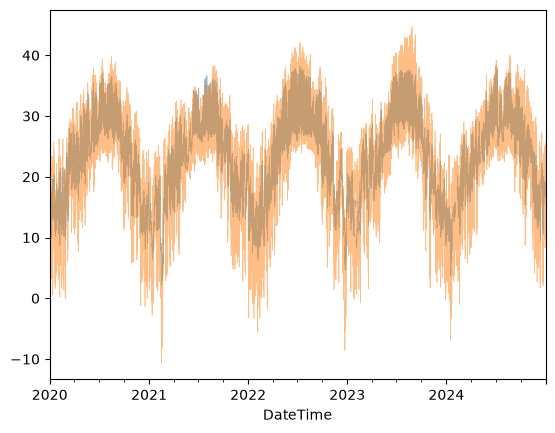

In [12]:
df_combined['Water Temperature (C)'].plot(linewidth=0.5, alpha = 0.5)
df_combined['Air Temperature'].plot(linewidth=0.5, alpha = 0.5)

<Axes: xlabel='DateTime'>

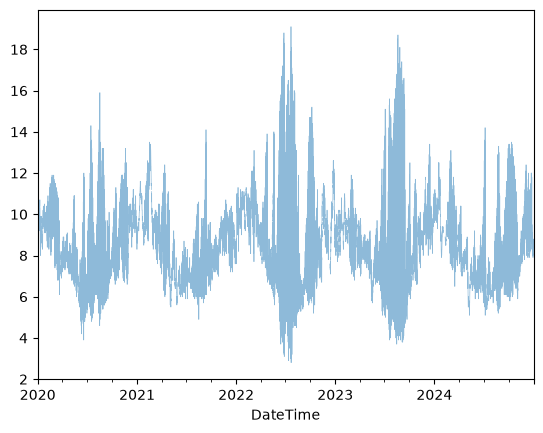

In [13]:
df_combined['Dissolved Oxygen (mg/L)'].plot(linewidth=0.5, alpha = 0.5)

<Axes: xlabel='DateTime'>

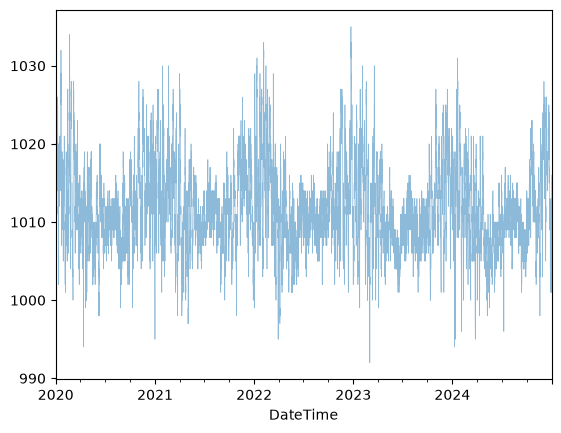

In [14]:
df_combined['Pressure'].plot(linewidth=0.5, alpha = 0.5)

In [15]:
df_combined.columns

Index(['Discharge (cfs)', 'Water Temperature (C)', 'pH (std units)',
       'Dissolved Oxygen (mg/L)', 'Specific Conductance (uS/cm)',
       'Turbidity (NTU)', 'Year', 'Month', 'Day', 'Hour', 'Minute',
       'Air Temperature', 'Alpha', 'Aerosol Optical Depth', 'Asymmetry',
       'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'Cloud Fill Flag',
       'Cloud Type', 'Dew Point', 'DHI', 'DNI', 'Fill Flag', 'GHI', 'Ozone',
       'Relative Humidity', 'Solar Zenith Angle', 'SSA', 'Surface Albedo',
       'Pressure', 'Precipitable Water', 'Wind Direction', 'Wind Speed',
       'DateTime', 'Smooth Wind Direction'],
      dtype='str')

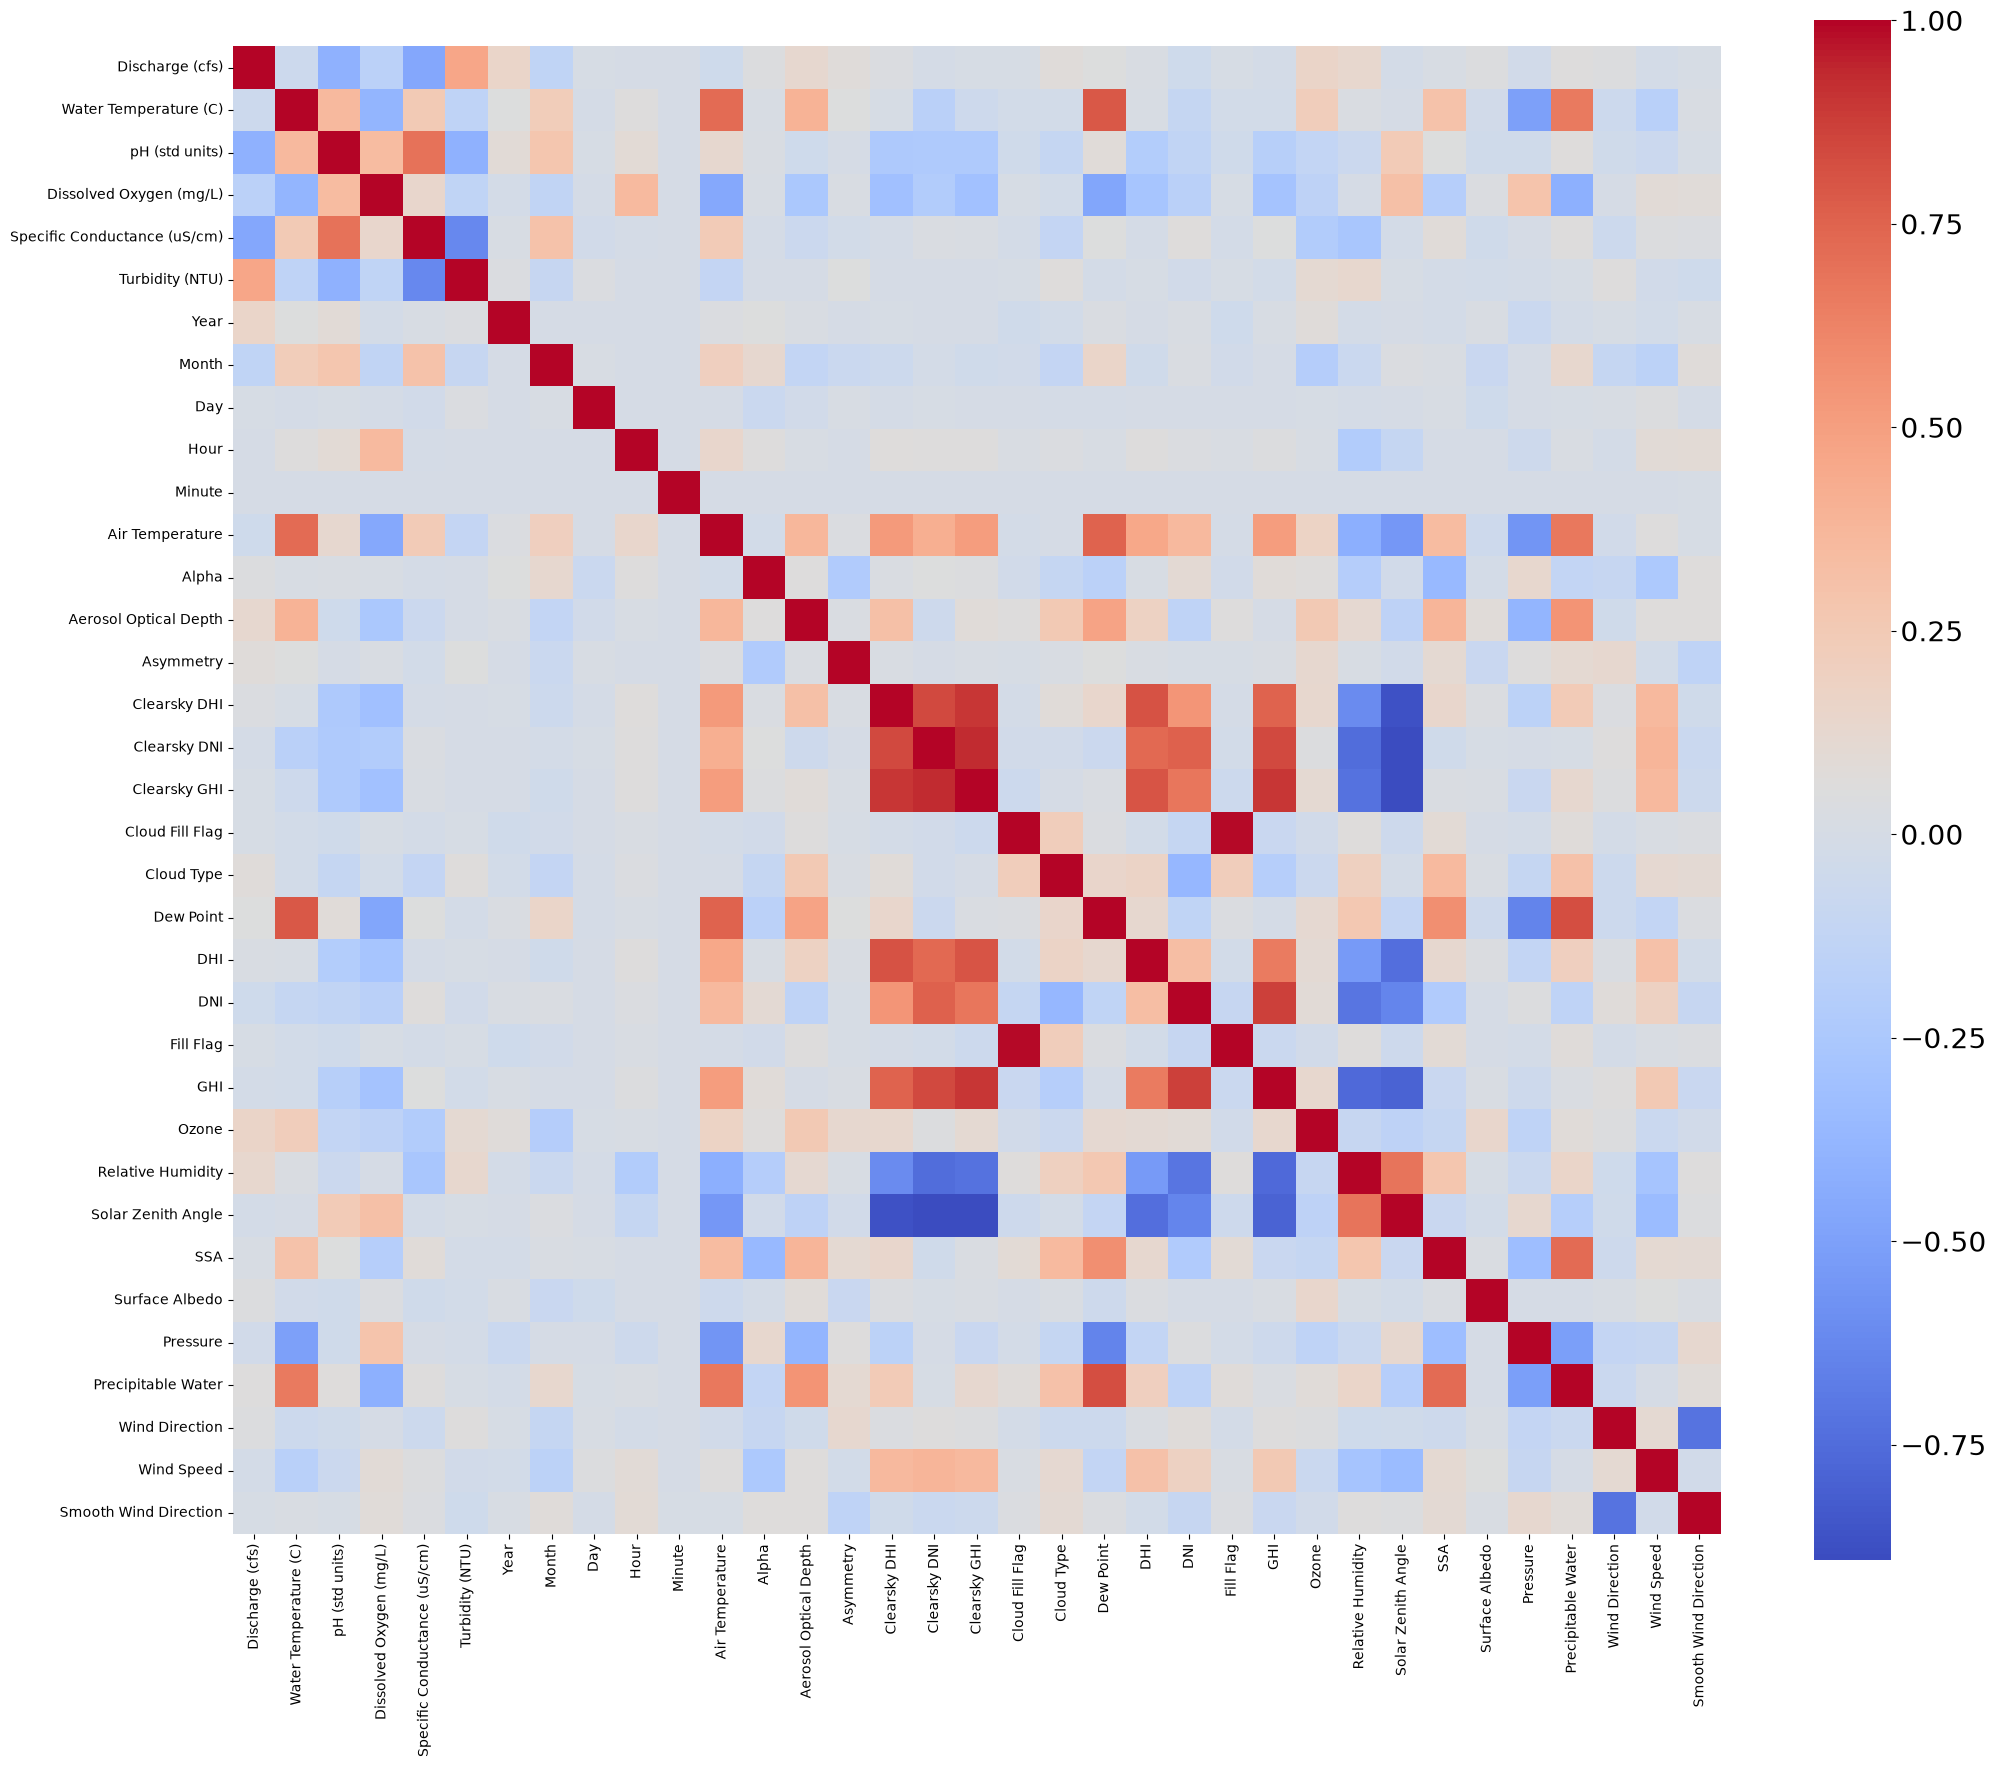

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(24,20))
num_cols = df_combined.select_dtypes(include=[np.number]).columns
num_cols = num_cols[:]
# num_cols = num_cols.append(merged.columns[-1:])
corr = df_combined[num_cols].corr(numeric_only=True)
plt.rcParams['font.size'] = 20
sns.heatmap(corr, annot=False, cmap="coolwarm",ax=ax)
ax.set_aspect(1)